In [1]:
import pyTauDEM

In [3]:
# Define the path of the DEM file and its name
dem_folder = r"D:\1_Postdoc\0_Data\DEM_Tiff"
filename = "ca_srtm_30m.tif"
# Resolution of the DEM in meters
res = 30
# Location of the point of interest
merced_lon, merced_lat = -120.3287384, 38.2027456

results = pyTauDEM.get_point_terrain(dem_folder, filename, merced_lon, merced_lat, res)
# 4. 打印结果
print(f"中心点海拔: {results['elevation']:.2f} m")
print(f"Tarboton 坡度: {results['slope']:.2f}")
print("顺时针邻居海拔 (E -> NE):")
print(results['adjacent_elevations'])

# 4. 调用绘图函数查看位置
# buffer=5 可以看全州，buffer=0.5 看局部
results.plot_location(merced_lon, merced_lat, buffer=2.0)
# 5. 完成后记得关闭文件
# ptd.close()

中心点海拔: 791.00 m
Tarboton 坡度: 0.00
顺时针邻居海拔 (E -> NE):
[791.0, 791.0, 791.0, 791.0, 791.0, 791.0, 791.0, 791.0]


AttributeError: 'dict' object has no attribute 'plot_location'

------------------------------
[pyTauDEM 诊断信息]
1. DEM 坐标系 (CRS): EPSG:4326
2. 坐标系单位: unknown
3. 偏移量换算: 30米 ≈ 0.000269度
4. DEM 覆盖范围: Lon(-124.87 to -112.59), Lat(32.01 to 42.31)
------------------------------
中心点海拔: 85.00 m
海拔标准差 (STD): 0.74 m
局部最大高差 (Range): 2.00 m
Tarboton 坡度: 0.05
顺时针邻居海拔 (E -> NE):
[84.0, 84.0, 85.0, 84.0, 85.0, 86.0, 86.0, 85.0]


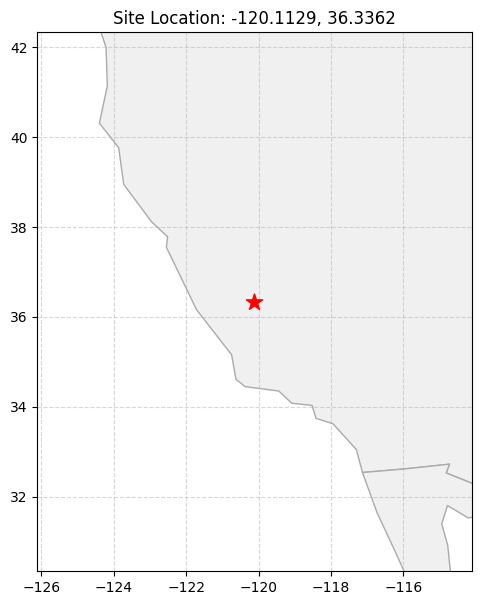

In [4]:
import pyTauDEM

# 1. 定义路径和参数
dem_folder = r"D:\1_Postdoc\0_Data\DEM_Tiff"
filename = "ca_srtm_30m.tif"
res = 30
merced_lon, merced_lat = -120.112906, 36.336222

# 2. 实例化类（这样你才能使用类里面的 plot_location 方法）
ptd = pyTauDEM.pyTauDEM(dem_folder, filename)

# 3. 获取地形数据
results = ptd.get_terrain_data(merced_lon, merced_lat, res)

# 4. 打印结果
print(f"中心点海拔: {results['elevation']:.2f} m")
print(f"海拔标准差 (STD): {results['std_elevation']:.2f} m")
print(f"局部最大高差 (Range): {results['max_elevation_difference']:.2f} m")
print(f"Tarboton 坡度: {results['slope']:.2f}")
print("顺时针邻居海拔 (E -> NE):")
print(results['adjacent_elevations'])

ptd.plot_location(merced_lon, merced_lat, buffer=6)
ptd.close()

# Extracting values from the results dictionary
elev, std, diff, slope = results['elevation'], results['std_elevation'], results['max_elevation_difference'], results['slope']
# Elevation for those adjacent 8 grids
[e, se, s, sw, w, nw, n, ne] = results['adjacent_elevations']